In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('Synthetic_Transaction_Risk_Dataset.xlsx')

In [4]:
df.shape


(10000, 20)

In [10]:
df.head()

,TransactionID,Timestamp,CustomerID,MerchantID,MerchantCategory,City,State,PaymentMethod,DeviceType,Amount,TransactionHour,IsWeekend,AccountAgeDays,PrevTxn24H,AvgCustomerAmount,AmountDeviation,MerchantRiskScore,DeviceChanged,LocationChanged,IsFraud
0,TX0000001,2025-09-02 10:50:00,C01334,M0410,Fashion,Jaipur,Rajasthan,Credit Card,Windows,503.13,10,0,1359,0,441.11,0.14,0.16,0,0,0
1,TX0000002,2025-07-17 18:48:00,C02203,M0379,Fuel,Pune,Maharashtra,Credit Card,iPhone,2360.42,18,0,1072,1,2439.00,-0.03,0.97,0,0,0
2,TX0000003,2025-09-02 20:40:00,C02304,M0195,Food,Pune,Maharashtra,Debit Card,Android,1940.09,20,0,228,2,2080.68,-0.07,0.50,0,0,0
3,TX0000004,2025-10-23 11:46:00,C01084,M0051,Grocery,Pune,Maharashtra,Wallet,iPhone,1452.12,11,0,725,3,765.94,0.90,0.93,1,0,0
4,TX0000005,2025-09-21 08:07:00,C00820,M0423,Electronics,Jaipur,Rajasthan,Credit Card,Android,519.49,8,1,403,2,3362.47,-0.85,0.93,0,0,0


In [5]:
n_fraud = (df['IsFraud'] == 1).sum()
n_not_fraud = df.shape[0] - n_fraud

In [6]:
fraud_counts = df['IsFraud'].value_counts()

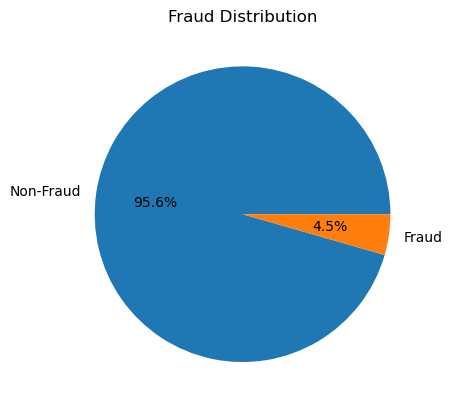

In [9]:
plt.pie(
    fraud_counts,
    labels=['Non-Fraud', 'Fraud'],
    autopct='%1.1f%%'
)
plt.title('Fraud Distribution')
plt.show()

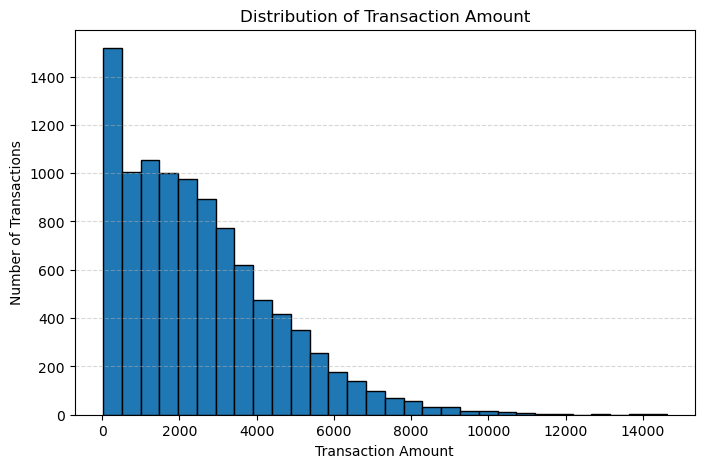

In [31]:
plt.figure(figsize=(8,5))
plt.hist(
    df['Amount'],
    bins=30,
    edgecolor='black'
)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

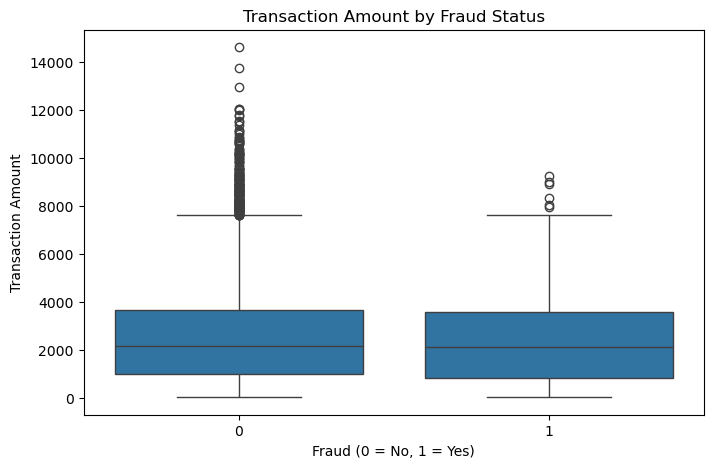

In [32]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='IsFraud',
    y='Amount',
    data=df
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")

plt.show()

In [18]:
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour
fraud_hour = df[df['IsFraud']==1]['Hour'].value_counts().sort_index()

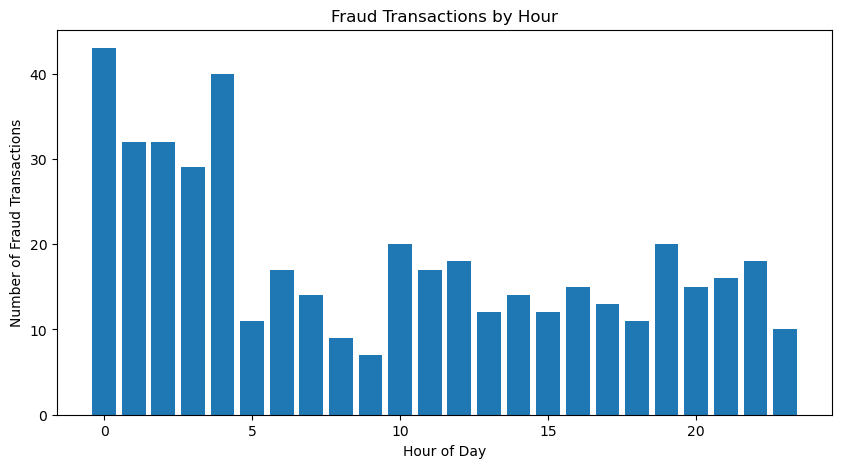

In [19]:
plt.figure(figsize=(10,5))
plt.bar(fraud_hour.index, fraud_hour.values)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Fraud Transactions")
plt.show()

In [22]:
top_merchants = df[df['IsFraud']==1]['MerchantID'].value_counts().head(10)



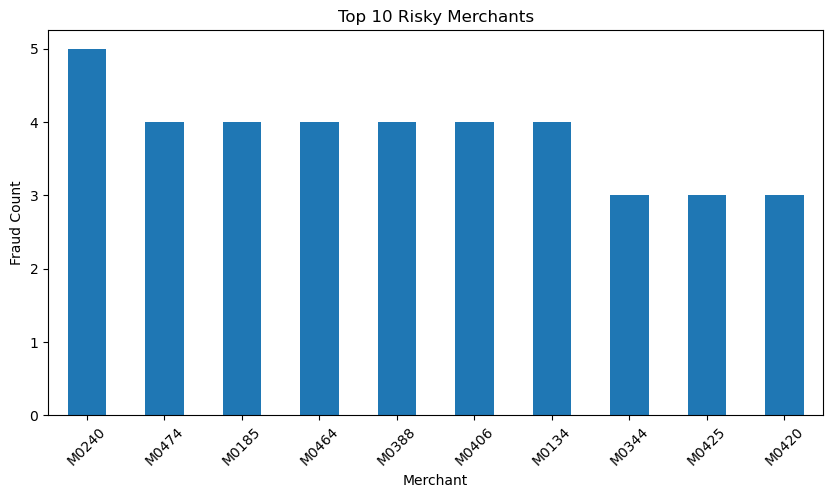

In [23]:
plt.figure(figsize=(10,5))
top_merchants.plot(kind='bar')

plt.title("Top 10 Risky Merchants")
plt.xlabel("Merchant")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.show()

In [24]:
fraud_payment = df[df['IsFraud']==1]['PaymentMethod'].value_counts()

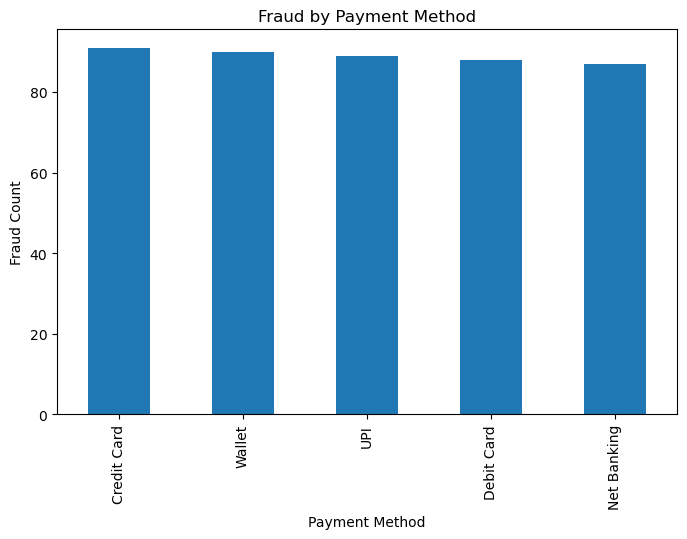

In [25]:
plt.figure(figsize=(8,5))
fraud_payment.plot(kind='bar')

plt.title("Fraud by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fraud Count")
plt.show()

In [26]:
fraud_device = df[df['IsFraud']==1]['DeviceType'].value_counts()

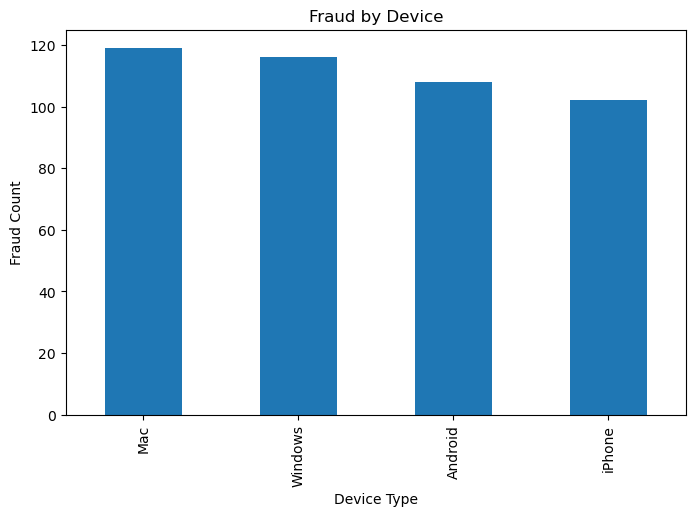

In [27]:

plt.figure(figsize=(8,5))
fraud_device.plot(kind='bar')

plt.title("Fraud by Device")
plt.xlabel("Device Type")
plt.ylabel("Fraud Count")
plt.show()

In [28]:
fraud_city = df[df['IsFraud']==1]['City'].value_counts().head(10)

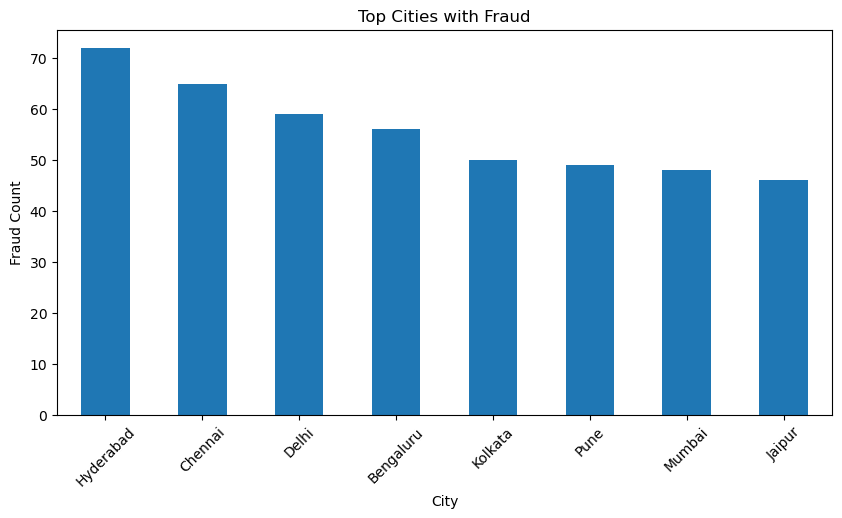

In [29]:

plt.figure(figsize=(10,5))
fraud_city.plot(kind='bar')

plt.title("Top Cities with Fraud")
plt.xlabel("City")
plt.ylabel("Fraud Count")
plt.xticks(rotation=45)
plt.show()

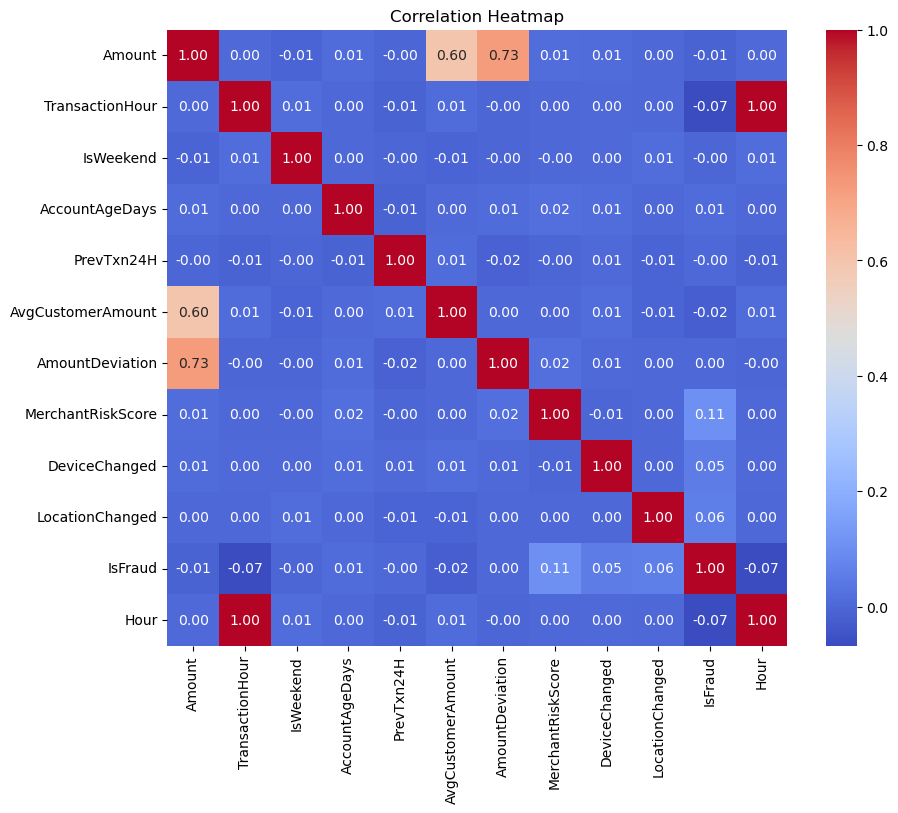

In [30]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

# Business Insights & Recommendations

## 1. Fraud Distribution
### Observation
The fraud rate is approximately 4.5%, while 95.5% of all transactions are legitimate.

### Business Interpretation

The low fraud rate indicates that fraudulent transactions are relatively rare but potentially high-impact. Since legitimate transactions constitute the majority of payment volume, manually reviewing every transaction would significantly increase operational costs and customer friction.

### Recommendation

A risk-based fraud detection framework should be implemented to prioritize high-risk transactions for investigation while allowing low-risk transactions to be processed seamlessly. This approach minimizes operational workload while maintaining strong fraud prevention.

## 2. Transaction Amount Distribution
### Observation

Most transactions fall within the ₹1,500–₹3,500 range, with only a small proportion representing very high-value transactions.

### Business Interpretation

Customer spending follows a relatively consistent pattern. Transactions that deviate significantly from a customer's normal spending behaviour may represent elevated fraud risk rather than normal purchasing activity.

### Recommendation

Instead of applying static transaction limits, implement customer-specific behavioural thresholds that compare each transaction against the customer's historical spending profile.


## 3. Fraud Transactions by Hour
### Observation

Fraud activity is highest during midnight to early morning hours (12 AM–5 AM), with noticeably lower activity during regular business hours.

### Business Interpretation

Fraudsters appear to exploit periods when customers are less likely to actively monitor account activity, increasing the likelihood of unauthorized transactions remaining undetected for longer periods.

### Recommendation

Increase fraud monitoring sensitivity during overnight hours by:

Lowering fraud detection thresholds.
Triggering additional customer authentication for high-value transactions.
Increasing real-time alert generation for suspicious overnight activity.

## 4. Top Risky Merchants
### Observation

A small group of merchants consistently appears more frequently in fraudulent transactions than others.

### Business Interpretation

These merchants may represent industries or businesses that are more frequently targeted by fraudsters. While this does not necessarily indicate merchant misconduct, it highlights areas requiring enhanced monitoring.

### Recommendation

Develop a dynamic Merchant Risk Score that continuously updates based on fraud frequency, historical chargebacks, transaction velocity, and behavioural trends. High-risk merchants should receive enhanced transaction screening.

## 5. Fraud by Payment Method
### Observation

Fraud occurrences are relatively evenly distributed across payment methods, including Credit Card, Wallet, UPI, Debit Card, and Net Banking.

### Business Interpretation

No individual payment method appears disproportionately vulnerable in the current dataset. Fraud attempts are distributed across multiple payment channels.

### Recommendation

Fraud prevention strategies should remain channel-agnostic by applying consistent fraud detection rules across all payment methods while incorporating behavioural signals rather than relying solely on payment type.

## 6. Fraud by Device Type
### Observation

Fraud transactions are observed across Mac, Windows, Android, and iPhone devices without a significant concentration in any single device category.

### Business Interpretation

Device type alone provides limited predictive value. However, changes in device usage may still indicate suspicious account activity.

### Recommendation

Instead of monitoring device type independently, implement device fingerprinting and detect unusual device changes combined with customer login history and behavioural patterns.


## 7. Fraud by City
### Observation

Cities such as Hyderabad, Chennai, and Delhi report a relatively higher number of fraudulent transactions.

### Business Interpretation

Higher fraud counts may reflect larger transaction volumes rather than inherently higher fraud risk. Therefore, transaction volume must be considered before drawing conclusions about geographic risk.

### Recommendation

Monitor Fraud Rate (%) instead of absolute fraud count by calculating:

Fraud Rate = Fraud Transactions ÷ Total Transactions

This enables accurate identification of genuinely high-risk geographic regions and supports efficient allocation of fraud investigation resources.

## 8. Correlation Analysis
### Observation

The strongest positive relationships observed include:

Transaction Amount ↔ Account Deviation (0.73)
Transaction Amount ↔ Customer Average Amount (0.60)

Fraud shows relatively weak individual correlations with all features, with Merchant Risk Score exhibiting the highest positive relationship.

### Business Interpretation

Fraud is not driven by a single variable but rather by the interaction of multiple behavioural indicators. Individual features provide limited predictive power when evaluated independently.

Behavioural features such as spending deviation, merchant risk, location changes, and device changes collectively contribute more effectively to fraud identification.

### Recommendation

Develop a machine learning-based risk scoring model that evaluates multiple behavioural features simultaneously instead of relying on isolated business rules.

## Overall Business Findings

The exploratory analysis indicates that fraudulent behaviour is primarily behaviour-driven rather than transaction-driven. Fraudulent transactions cannot be accurately identified using transaction amount or payment method alone. Instead, fraud risk increases when multiple behavioural indicators occur together, including unusual spending behaviour, elevated merchant risk, changes in customer location or device, and transactions executed during high-risk time windows.

The analysis also highlights opportunities to improve fraud prevention by implementing dynamic risk scoring, strengthening overnight transaction monitoring, continuously updating merchant risk profiles, and replacing static rule-based controls with behavioural analytics.